In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

In [3]:
DATA_DIR = Path("../data/raw")

metadata_path = DATA_DIR / "HAM10000_metadata.csv"

df = pd.read_csv(metadata_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (10015, 7)


In [4]:
df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [7]:
df.info()
print(df.columns.tolist())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   image_id      10015 non-null  object 
 2   dx            10015 non-null  object 
 3   dx_type       10015 non-null  object 
 4   age           9958 non-null   float64
 5   sex           10015 non-null  object 
 6   localization  10015 non-null  object 
dtypes: float64(1), object(6)
memory usage: 547.8+ KB
['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization']


In [10]:
df["dx"].unique()
df["dx"].nunique()

7

In [11]:
class_counts = df["dx"].value_counts()
print(class_counts)

dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


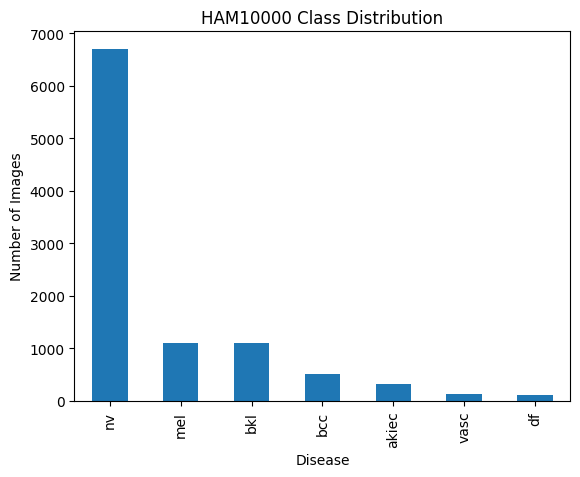

In [13]:
class_counts.plot(kind="bar")

plt.title("HAM10000 Class Distribution")
plt.xlabel("Disease")
plt.ylabel("Number of Images")

plt.show()

In [14]:
image_dirs = [
    DATA_DIR / "HAM10000_images_part_1",
    DATA_DIR / "HAM10000_images_part_2"
]

def find_image(image_id):
    for directory in image_dirs:
        image_path = directory / f"{image_id}.jpg"

        if image_path.exists():
            return image_path

    return None

In [15]:
row = df.iloc[0]

image_id = row["image_id"]
label = row["dx"]

print("Image ID", image_id)
print("Label:", label)

Image ID ISIC_0027419
Label: bkl


Image Path: ..\data\raw\HAM10000_images_part_1\ISIC_0027419.jpg


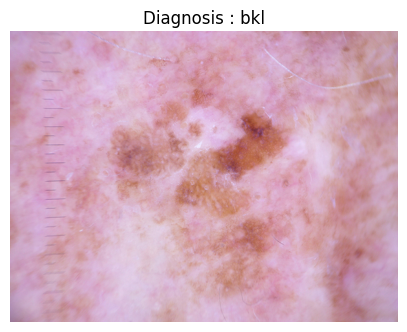

In [16]:
image_path = find_image(image_id)

print("Image Path:", image_path)


image = Image.open(image_path)

plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.axis("off")
plt.title(f"Diagnosis : {label}")

plt.show()

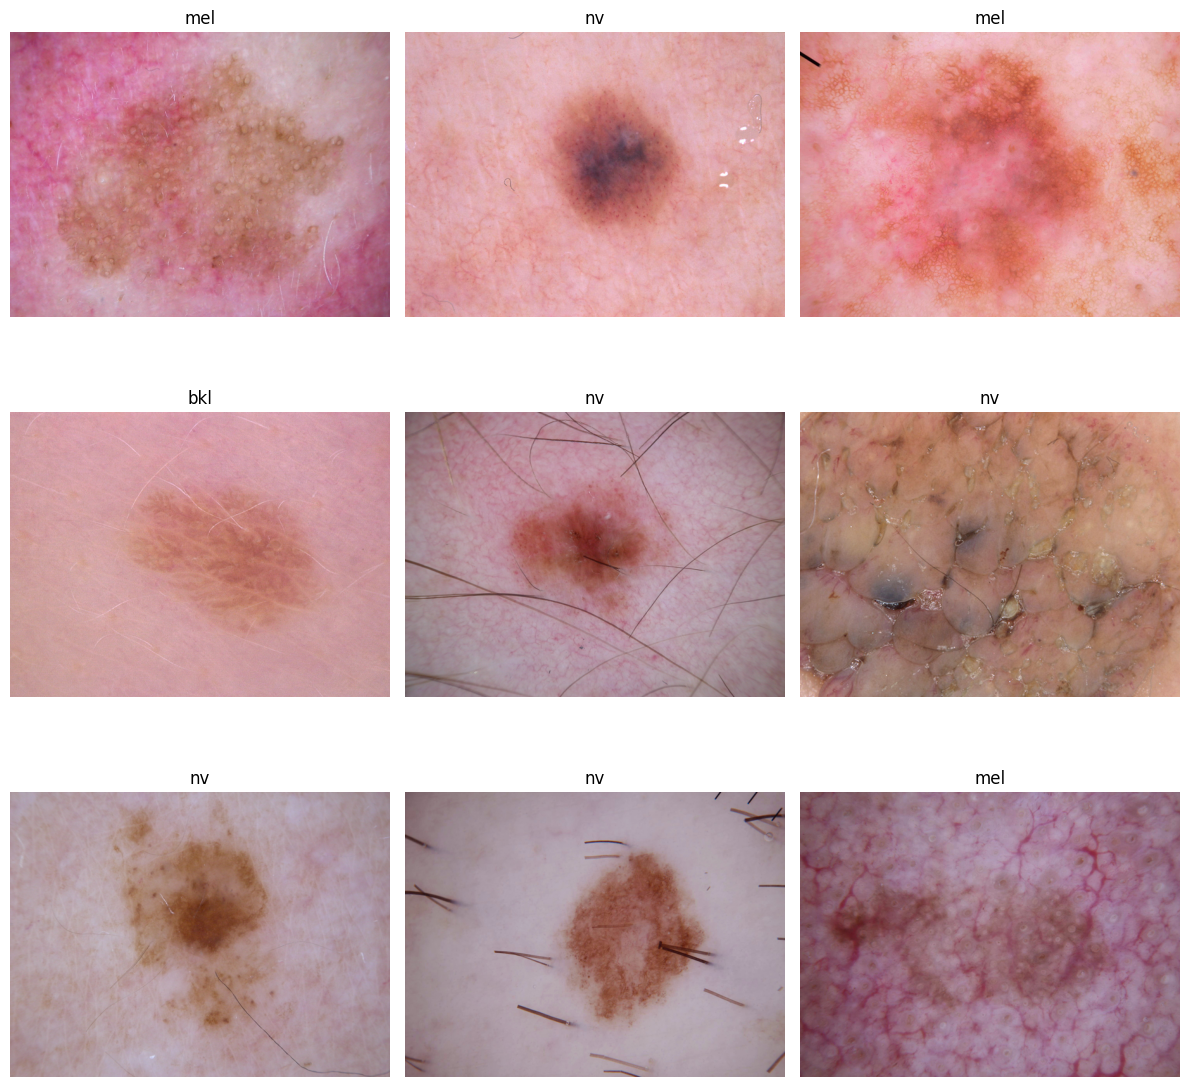

In [17]:
sample = df.sample(9, random_state=42)

plt.figure(figsize=(12, 12))

for i, (_, row) in enumerate(sample.iterrows()):

    image_path = find_image(row["image_id"])
    image = Image.open(image_path)

    plt.subplot(3, 3, i + 1)
    plt.imshow(image)
    plt.axis("off")
    plt.title(row["dx"])

plt.tight_layout()
plt.show()

In [18]:
print(df.shape)
print(df["dx"].value_counts())

(10015, 7)
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


In [19]:
print("Unique images:", df["image_id"].nunique())
print("Unique lesions:", df["lesion_id"].nunique())

Unique images: 10015
Unique lesions: 7470


In [20]:
lesion_counts = df["lesion_id"].value_counts()

print(lesion_counts.head(10))

lesion_id
HAM_0000835    6
HAM_0003789    6
HAM_0005263    6
HAM_0001863    6
HAM_0007427    5
HAM_0007343    5
HAM_0002364    5
HAM_0007367    5
HAM_0000893    5
HAM_0000959    4
Name: count, dtype: int64


In [21]:
print("Lesions with multiple images:",
      (lesion_counts > 1).sum())

Lesions with multiple images: 1956


In [22]:
lesion_labels = df.groupby("lesion_id")["dx"].nunique()

print("Lesions with multiple diagnoses:",
      (lesion_labels > 1).sum())

Lesions with multiple diagnoses: 0


In [23]:
print(df.isnull().sum())

lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
dtype: int64


In [24]:
from sklearn.model_selection import GroupShuffleSplit

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.30,
    random_state=42
)

train_idx, temp_idx = next(
    splitter.split(
        df,
        groups=df["lesion_id"]
    )
)

train_df = df.iloc[train_idx].copy()
temp_df = df.iloc[temp_idx].copy()

print("Train:", len(train_df))
print("Temporary:", len(temp_df))

Train: 7002
Temporary: 3013


In [25]:
splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.50,
    random_state=42
)

val_idx, test_idx = next(
    splitter.split(
        temp_df,
        groups=temp_df["lesion_id"]
    )
)

val_df = temp_df.iloc[val_idx].copy()
test_df = temp_df.iloc[test_idx].copy()

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 7002
Validation: 1519
Test: 1494


In [26]:
train_lesions = set(train_df["lesion_id"])
val_lesions = set(val_df["lesion_id"])
test_lesions = set(test_df["lesion_id"])

print("Train ∩ Validation:",
      len(train_lesions & val_lesions))

print("Train ∩ Test:",
      len(train_lesions & test_lesions))

print("Validation ∩ Test:",
      len(val_lesions & test_lesions))

Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


In [27]:
print("TRAIN")
print(train_df["dx"].value_counts())

print("\nVALIDATION")
print(val_df["dx"].value_counts())

print("\nTEST")
print(test_df["dx"].value_counts())

TRAIN
dx
nv       4718
mel       770
bkl       741
bcc       381
akiec     207
vasc       96
df         89
Name: count, dtype: int64

VALIDATION
dx
nv       991
bkl      206
mel      156
bcc       65
akiec     57
vasc      25
df        19
Name: count, dtype: int64

TEST
dx
nv       996
mel      187
bkl      152
bcc       68
akiec     63
vasc      21
df         7
Name: count, dtype: int64


In [28]:
print(
    train_df["dx"].value_counts(normalize=True) * 100
)

print(
    val_df["dx"].value_counts(normalize=True) * 100
)

print(
    test_df["dx"].value_counts(normalize=True) * 100
)

dx
nv       67.380748
mel      10.996858
bkl      10.582691
bcc       5.441302
akiec     2.956298
vasc      1.371037
df        1.271065
Name: proportion, dtype: float64
dx
nv       65.240290
bkl      13.561554
mel      10.269914
bcc       4.279131
akiec     3.752469
vasc      1.645820
df        1.250823
Name: proportion, dtype: float64
dx
nv       66.666667
mel      12.516734
bkl      10.174029
bcc       4.551539
akiec     4.216867
vasc      1.405622
df        0.468541
Name: proportion, dtype: float64


In [29]:
from sklearn.model_selection import StratifiedGroupKFold

sgkf = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for train_idx, test_idx in sgkf.split(
    df,
    y=df["dx"],
    groups=df["lesion_id"]
):
    train_df = df.iloc[train_idx].copy()
    test_df = df.iloc[test_idx].copy()
    break

In [30]:
from sklearn.model_selection import StratifiedGroupKFold

sgkf = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for train_idx, test_idx in sgkf.split(
    df,
    y=df["dx"],
    groups=df["lesion_id"]
):
    sg_train = df.iloc[train_idx]
    sg_test = df.iloc[test_idx]
    break

print("TRAIN")
print(sg_train["dx"].value_counts())
print()

print("TEST")
print(sg_test["dx"].value_counts())

print("TRAIN %")
print(
    (sg_train["dx"].value_counts(normalize=True) * 100).round(2)
)

print("\nTEST %")
print(
    (sg_test["dx"].value_counts(normalize=True) * 100).round(2)
)

train_lesions = set(sg_train["lesion_id"])
test_lesions = set(sg_test["lesion_id"])

print(
    "Train/Test lesion overlap:",
    len(train_lesions & test_lesions)
)

TRAIN
dx
nv       5364
mel       891
bkl       879
bcc       411
akiec     261
vasc      113
df         92
Name: count, dtype: int64

TEST
dx
nv       1341
mel       222
bkl       220
bcc       103
akiec      66
vasc       29
df         23
Name: count, dtype: int64
TRAIN %
dx
nv       66.96
mel      11.12
bkl      10.97
bcc       5.13
akiec     3.26
vasc      1.41
df        1.15
Name: proportion, dtype: float64

TEST %
dx
nv       66.92
mel      11.08
bkl      10.98
bcc       5.14
akiec     3.29
vasc      1.45
df        1.15
Name: proportion, dtype: float64
Train/Test lesion overlap: 0


In [31]:
sgkf_val = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

train_idx, val_idx = next(
    sgkf_val.split(
        sg_train,
        y=sg_train["dx"],
        groups=sg_train["lesion_id"]
    )
)

train_df = sg_train.iloc[train_idx].copy()
val_df = sg_train.iloc[val_idx].copy()
test_df = sg_test.copy()

In [32]:
print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 6408
Validation: 1603
Test: 2004


In [33]:
train_lesions = set(train_df["lesion_id"])
val_lesions = set(val_df["lesion_id"])
test_lesions = set(test_df["lesion_id"])

print(
    "Train ∩ Validation:",
    len(train_lesions & val_lesions)
)

print(
    "Train ∩ Test:",
    len(train_lesions & test_lesions)
)

print(
    "Validation ∩ Test:",
    len(val_lesions & test_lesions)
)

Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


In [34]:
print("========== TRAIN ==========")
print(train_df["dx"].value_counts())

print("\n========== VALIDATION ==========")
print(val_df["dx"].value_counts())

print("\n========== TEST ==========")
print(test_df["dx"].value_counts())

========== TRAIN ==========
dx
nv       4291
mel       713
bkl       703
bcc       329
akiec     209
vasc       90
df         73
Name: count, dtype: int64

========== VALIDATION ==========
dx
nv       1073
mel       178
bkl       176
bcc        82
akiec      52
vasc       23
df         19
Name: count, dtype: int64

========== TEST ==========
dx
nv       1341
mel       222
bkl       220
bcc       103
akiec      66
vasc       29
df         23
Name: count, dtype: int64


In [36]:
print("========== TRAIN % ==========")
print(
    (train_df["dx"].value_counts(normalize=True) * 100).round(2)
)

print("\n========== VALIDATION % ==========")
print(
    (val_df["dx"].value_counts(normalize=True) * 100).round(2)
)

print("\n========== TEST % ==========")
print(
    (test_df["dx"].value_counts(normalize=True) * 100).round(2)
)

========== TRAIN % ==========
dx
nv       66.96
mel      11.13
bkl      10.97
bcc       5.13
akiec     3.26
vasc      1.40
df        1.14
Name: proportion, dtype: float64

========== VALIDATION % ==========
dx
nv       66.94
mel      11.10
bkl      10.98
bcc       5.12
akiec     3.24
vasc      1.43
df        1.19
Name: proportion, dtype: float64

========== TEST % ==========
dx
nv       66.92
mel      11.08
bkl      10.98
bcc       5.14
akiec     3.29
vasc      1.45
df        1.15
Name: proportion, dtype: float64


In [37]:
split_dir = Path("../data/processed")
split_dir.mkdir(parents=True, exist_ok=True)

train_df.to_csv(split_dir / "train.csv", index=False)
val_df.to_csv(split_dir / "validation.csv", index=False)
test_df.to_csv(split_dir / "test.csv", index=False)

print("Dataset splits saved!")

Dataset splits saved!
